In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import time

In [45]:
print("Fetching MNIST dataset")
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

X = mnist.data.values.astype('float32') / 255.0
y = mnist.target.values.astype('int')

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, test_size=10000, random_state=42)
print(f"{X_train.shape[0]} train samples, {X_test.shape[0]} test samples.\n")

Fetching MNIST dataset
60000 train samples, 10000 test samples.



In [46]:
d = 2
T_exp = 2  
epochs = int(T_exp)

M_x_list = [] # Stores mistake features for each class
M_y_list = [] # Stores mistake labels for each class
C_vecs = []   # Stores survival times

print(f"Starting Kernel Training (d={d}, T={T_exp})")
start_train_time = time.time()

for c in range(10):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)
    
    mistakes = []
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_bin[i]
            
            if len(mistakes) == 0:
                v_dot_x = 0.0
            else:
                # Vectorized kernel calculation against all historical mistakes
                M_x_arr = np.array([m[0] for m in mistakes])
                M_y_arr = np.array([m[1] for m in mistakes])
                v_dot_x = np.sum(M_y_arr * ((np.dot(M_x_arr, x_i) + 1.0) ** d))
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                mistakes.append((x_i, y_i))
                C.append(1)
                
    # Save the history matrices for this class
    if len(mistakes) > 0:
        M_x_list.append(np.array([m[0] for m in mistakes]))
        M_y_list.append(np.array([m[1] for m in mistakes]))
    else:
        M_x_list.append(np.empty((0, X_train.shape[1])))
        M_y_list.append(np.empty(0))
        
    C_vecs.append(np.array(C))
    print(f"  Class {c} completed in {time.time() - c_start_time:.1f}s | Total mistakes: {len(mistakes)}")

print(f"Total time: {time.time() - start_train_time:.1f}s\n")

Starting Kernel Training (d=2, T=2)
  Class 0 completed in 90.9s | Total mistakes: 813
  Class 1 completed in 74.4s | Total mistakes: 684
  Class 2 completed in 147.0s | Total mistakes: 1489
  Class 3 completed in 180.0s | Total mistakes: 1924
  Class 4 completed in 142.1s | Total mistakes: 1378
  Class 5 completed in 155.9s | Total mistakes: 1606
  Class 6 completed in 102.1s | Total mistakes: 978
  Class 7 completed in 133.8s | Total mistakes: 1378
  Class 8 completed in 211.1s | Total mistakes: 2329
  Class 9 completed in 219.2s | Total mistakes: 2444
Total time: 1456.6s



In [47]:
print("Evaluating")
start_eval_time = time.time()

batch_size = 1000
y_pred_all = np.zeros(len(X_test))
conf_method_2 = np.zeros(len(X_test))

for i in range(0, len(X_test), batch_size):
    X_batch = X_test[i:i+batch_size]
    batch_scores = np.zeros((len(X_batch), 10))
    batch_signs_list = []
    
    for c in range(10):
        if len(M_x_list[c]) > 0:
            K_matrix = (np.dot(X_batch, M_x_list[c].T) + 1.0) ** d
            K_weighted = K_matrix * M_y_list[c]
            
            H_vals = np.hstack([np.zeros((len(X_batch), 1)), np.cumsum(K_weighted, axis=1)])
            signs = np.where(H_vals >= 0, 1, -1)
            
            batch_signs_list.append(signs)
            batch_scores[:, c] = np.dot(signs, C_vecs[c])
        else:
            batch_signs_list.append(np.ones((len(X_batch), 1)))
            batch_scores[:, c] = np.ones(len(X_batch)) * C_vecs[c][0]
            
    y_pred_batch = np.argmax(batch_scores, axis=1)
    y_pred_all[i:i+batch_size] = y_pred_batch
    
    for j in range(len(X_batch)):
        winner = y_pred_batch[j]
        global_j = i + j
        
        # --- Unbroken Streak ---
        signs_winner = batch_signs_list[winner][j]
        last_vote = signs_winner[-1]
        reversed_signs = signs_winner[::-1]
        matches = (reversed_signs == last_vote)
        streak = len(signs_winner) if np.all(matches) else np.argmin(matches)
        conf_method_2[global_j] = streak

    print(f"  Processed batch {i} to {i+len(X_batch)}...")

print(f"Evaluation Complete! Total time: {time.time() - start_eval_time:.1f}s\n")

Evaluating
  Processed batch 0 to 1000...
  Processed batch 1000 to 2000...
  Processed batch 2000 to 3000...
  Processed batch 3000 to 4000...
  Processed batch 4000 to 5000...
  Processed batch 5000 to 6000...
  Processed batch 6000 to 7000...
  Processed batch 7000 to 8000...
  Processed batch 8000 to 9000...
  Processed batch 9000 to 10000...
Evaluation Complete! Total time: 3.2s



Generating Plots


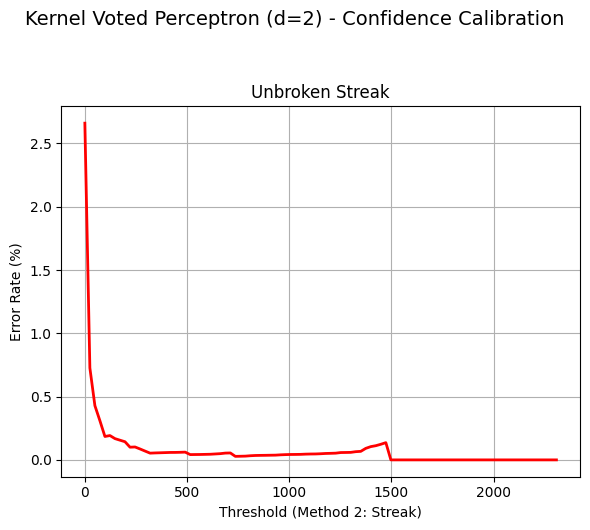

In [48]:
print("Generating Plots")
mistakes_mask = (y_pred_all != y_test)

def get_error_rates(confidences, mistakes):
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        # Enforce minimum 20 samples to prevent crazy random spikes at the end
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

t2, err2 = get_error_rates(conf_method_2, mistakes_mask)

fig, ax2 = plt.subplots(figsize=(6, 5))

# Plot
ax2.plot(t2, err2, 'r-', linewidth=2)
ax2.set_xlabel('Threshold (Method 2: Streak)')
ax2.set_ylabel('Error Rate (%)')
ax2.set_title('Unbroken Streak')
ax2.grid(True)

plt.suptitle(f"Kernel Voted Perceptron (d={d}) - Confidence Calibration", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [49]:
def train_predict_linear(X_tr, y_bin, X_test, epochs):
    """Runs One-vs-All Linear Perceptron and returns only Voting & Streak data."""
    V = [np.zeros(X_tr.shape[1])]
    C = [0]

    for epoch in range(epochs):
        for i in range(len(X_tr)):
            x_i = X_tr[i]
            y_i = y_bin[i]

            y_hat = 1 if np.dot(V[-1], x_i) >= 0 else -1

            if y_hat == y_i:
                C[-1] += 1
            else:
                V.append(V[-1] + y_i * x_i)
                C.append(1)

    V_mat = np.array(V)
    C_vec = np.array(C)

    # Calculate only the dot products and signs needed for standard voting and the streak
    dots = np.dot(X_test, V_mat.T)
    signs = np.where(dots >= 0, 1, -1)
    
    score_vote = np.dot(signs, C_vec)
    mistakes_count = len(V) - 1

    return score_vote, signs, mistakes_count

In [50]:
d = 1
T_exp = 2  
epochs = int(T_exp)

print(f"Starting Linear Training & Evaluation (d={d}, T={T_exp})")
start_time = time.time()

all_scores_vote = np.zeros((len(X_test), 10))
all_signs_list = [] 

for c in range(10):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)
    
    # Call the cleaned function
    score_vote, signs, mistakes = train_predict_linear(X_train, y_bin, X_test, epochs)
    
    all_scores_vote[:, c] = score_vote
    all_signs_list.append(signs)
    
    print(f"  Class {c} completed in {time.time() - c_start_time:.1f}s | Total mistakes: {mistakes}")

# Determine the final predicted class
y_pred_all = np.argmax(all_scores_vote, axis=1)
conf_method_2 = np.zeros(len(X_test))

# Calculate Unbroken Streak (Method 2)
for j in range(len(X_test)):
    winner = y_pred_all[j]
    
    # Extract the vote history of the winning class
    signs_winner = all_signs_list[winner][j]
    last_vote = signs_winner[-1]
    
    reversed_signs = signs_winner[::-1]
    matches = (reversed_signs == last_vote)
    
    if np.all(matches):
        streak = len(signs_winner)
    else:
        streak = np.argmin(matches) 
        
    conf_method_2[j] = streak

print(f"Total time: {time.time() - start_time:.1f}s\n")

Starting Linear Training & Evaluation (d=1, T=2)
  Class 0 completed in 0.7s | Total mistakes: 2042
  Class 1 completed in 0.7s | Total mistakes: 1773
  Class 2 completed in 1.1s | Total mistakes: 4605
  Class 3 completed in 1.2s | Total mistakes: 5551
  Class 4 completed in 1.0s | Total mistakes: 3698
  Class 5 completed in 1.3s | Total mistakes: 5787
  Class 6 completed in 0.9s | Total mistakes: 2919
  Class 7 completed in 0.9s | Total mistakes: 3264
  Class 8 completed in 1.9s | Total mistakes: 10517
  Class 9 completed in 1.6s | Total mistakes: 7839
Total time: 11.3s



Generating Plots


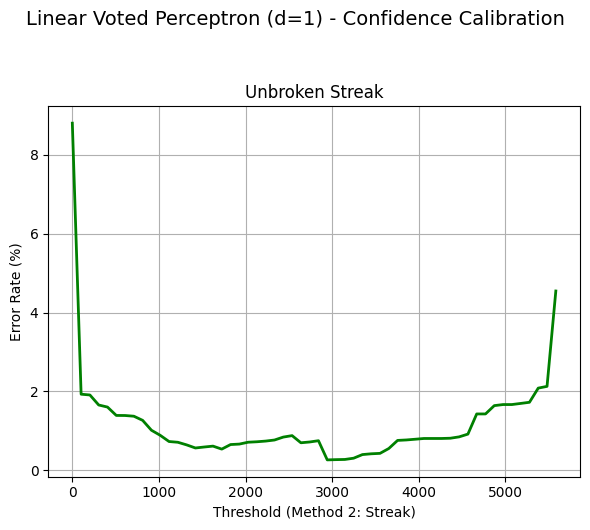

In [51]:
print("Generating Plots")
mistakes_mask = (y_pred_all != y_test)

def get_error_rates(confidences, mistakes):
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        # Enforce minimum 20 samples to prevent crazy random spikes at the end
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

t2, err2 = get_error_rates(conf_method_2, mistakes_mask)

fig, ax2 = plt.subplots(figsize=(6, 5))

# Plot
ax2.plot(t2, err2, 'g-', linewidth=2)
ax2.set_xlabel('Threshold (Method 2: Streak)')
ax2.set_ylabel('Error Rate (%)')
ax2.set_title('Unbroken Streak')
ax2.grid(True)

plt.suptitle(f"Linear Voted Perceptron (d={d}) - Confidence Calibration", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [52]:
d = 1
T_exp = 2  
epochs = int(T_exp)

M_x_list = [] # Stores mistake features for each class
M_y_list = [] # Stores mistake labels for each class
C_vecs = []   # Stores survival times

print(f"Starting Kernel Training (d={d}, T={T_exp})")
start_train_time = time.time()

for c in range(10):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)
    
    mistakes = []
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_bin[i]
            
            if len(mistakes) == 0:
                v_dot_x = 0.0
            else:
                # Vectorized kernel calculation against all historical mistakes
                M_x_arr = np.array([m[0] for m in mistakes])
                M_y_arr = np.array([m[1] for m in mistakes])
                v_dot_x = np.sum(M_y_arr * ((np.dot(M_x_arr, x_i) + 1.0) ** d))
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                mistakes.append((x_i, y_i))
                C.append(1)
                
    # Save the history matrices for this class
    if len(mistakes) > 0:
        M_x_list.append(np.array([m[0] for m in mistakes]))
        M_y_list.append(np.array([m[1] for m in mistakes]))
    else:
        M_x_list.append(np.empty((0, X_train.shape[1])))
        M_y_list.append(np.empty(0))
        
    C_vecs.append(np.array(C))
    print(f"  Class {c} completed in {time.time() - c_start_time:.1f}s | Total mistakes: {len(mistakes)}")

print(f"Total time: {time.time() - start_train_time:.1f}s\n")

Starting Kernel Training (d=1, T=2)
  Class 0 completed in 158.4s | Total mistakes: 1828
  Class 1 completed in 146.6s | Total mistakes: 1769
  Class 2 completed in 337.4s | Total mistakes: 4402
  Class 3 completed in 397.5s | Total mistakes: 5059
  Class 4 completed in 285.6s | Total mistakes: 3715
  Class 5 completed in 457.1s | Total mistakes: 5741
  Class 6 completed in 208.1s | Total mistakes: 2664
  Class 7 completed in 247.7s | Total mistakes: 3240
  Class 8 completed in 683.9s | Total mistakes: 7955
  Class 9 completed in 602.9s | Total mistakes: 7202
Total time: 3525.1s



In [53]:
print("Evaluating")
start_eval_time = time.time()

batch_size = 1000
y_pred_all = np.zeros(len(X_test))
conf_method_2 = np.zeros(len(X_test))

for i in range(0, len(X_test), batch_size):
    X_batch = X_test[i:i+batch_size]
    batch_scores = np.zeros((len(X_batch), 10))
    batch_signs_list = []
    
    for c in range(10):
        if len(M_x_list[c]) > 0:
            K_matrix = (np.dot(X_batch, M_x_list[c].T) + 1.0) ** d
            K_weighted = K_matrix * M_y_list[c]
            
            H_vals = np.hstack([np.zeros((len(X_batch), 1)), np.cumsum(K_weighted, axis=1)])
            signs = np.where(H_vals >= 0, 1, -1)
            
            batch_signs_list.append(signs)
            batch_scores[:, c] = np.dot(signs, C_vecs[c])
        else:
            batch_signs_list.append(np.ones((len(X_batch), 1)))
            batch_scores[:, c] = np.ones(len(X_batch)) * C_vecs[c][0]
            
    y_pred_batch = np.argmax(batch_scores, axis=1)
    y_pred_all[i:i+batch_size] = y_pred_batch
    
    for j in range(len(X_batch)):
        winner = y_pred_batch[j]
        global_j = i + j
        
        # --- Unbroken Streak ---
        signs_winner = batch_signs_list[winner][j]
        last_vote = signs_winner[-1]
        reversed_signs = signs_winner[::-1]
        matches = (reversed_signs == last_vote)
        streak = len(signs_winner) if np.all(matches) else np.argmin(matches)
        conf_method_2[global_j] = streak

    print(f"  Processed batch {i} to {i+len(X_batch)}...")

print(f"Evaluation Complete! Total time: {time.time() - start_eval_time:.1f}s\n")

Evaluating
  Processed batch 0 to 1000...
  Processed batch 1000 to 2000...
  Processed batch 2000 to 3000...
  Processed batch 3000 to 4000...
  Processed batch 4000 to 5000...
  Processed batch 5000 to 6000...
  Processed batch 6000 to 7000...
  Processed batch 7000 to 8000...
  Processed batch 8000 to 9000...
  Processed batch 9000 to 10000...
Evaluation Complete! Total time: 9.2s



Generating Plots


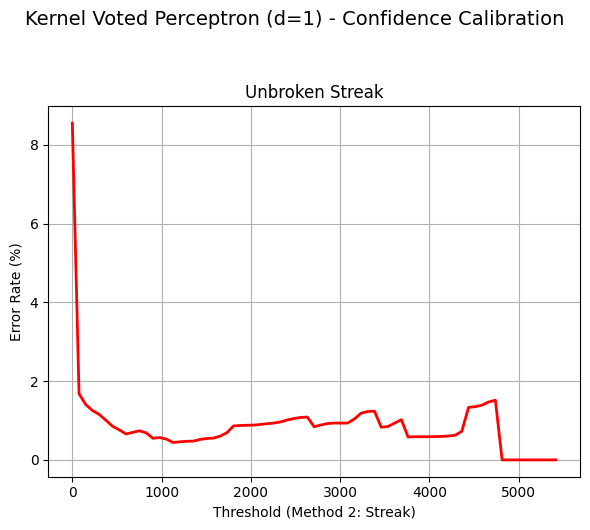

In [54]:
print("Generating Plots")
mistakes_mask = (y_pred_all != y_test)

def get_error_rates(confidences, mistakes):
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        # Enforce minimum 20 samples to prevent crazy random spikes at the end
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

t2, err2 = get_error_rates(conf_method_2, mistakes_mask)

fig, ax2 = plt.subplots(figsize=(6, 5))

# Plot
ax2.plot(t2, err2, 'r-', linewidth=2)
ax2.set_xlabel('Threshold (Method 2: Streak)')
ax2.set_ylabel('Error Rate (%)')
ax2.set_title('Unbroken Streak')
ax2.grid(True)

plt.suptitle(f"Kernel Voted Perceptron (d={d}) - Confidence Calibration", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()